In [1]:
import os
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from torch.utils.data import DataLoader, Subset, random_split

In [2]:
# PATHS

DATA_DIR = "../data/raw/fer2013"

train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

print("Train dir exists:", os.path.exists(train_dir))
print("Test dir exists:", os.path.exists(test_dir))

Train dir exists: True
Test dir exists: True


In [3]:
# TRANSFORMS

test_transform = val_transform = basic_trasform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [4]:
# DATASETS

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=basic_trasform
)

torch.manual_seed(42)

val_ratio = 0.15
n_total = len(train_dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

train_subset, val_subset = random_split(train_dataset, [n_train, n_val])

train_dataset_aug = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset_noaug = datasets.ImageFolder(
    root=train_dir,
    transform=val_transform
)

train_ids = train_subset.indices
val_ids = val_subset.indices

train_final = Subset(train_dataset_aug, train_ids)
val_final = Subset(val_dataset_noaug, val_ids)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

In [5]:
print("Train samples:", len(train_final))
print("Val samples:", len(val_final))
print("Test samples:", len(test_dataset))
print("Emotion classes:", train_dataset.classes)

Train samples: 24403
Val samples: 4306
Test samples: 7178
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171


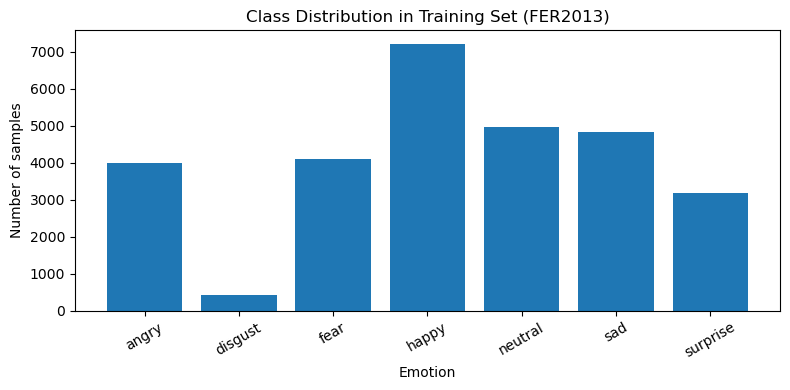

<Figure size 640x480 with 0 Axes>

In [11]:
train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

for id, class_name in enumerate(train_dataset.classes):
    print(f"{class_name}: {class_counts[id]}")

classes = train_dataset.classes
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(8, 4))
plt.bar(classes, counts)
plt.title("Class Distribution in Training Set (FER2013)")
plt.xlabel("Emotion")
plt.ylabel("Number of samples")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.savefig("../data/processed/class_distribution.png", dpi=200, bbox_inches="tight")

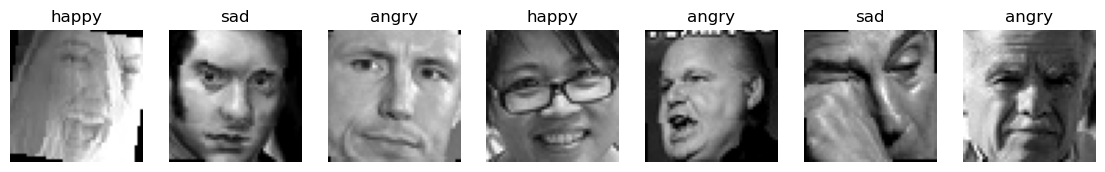

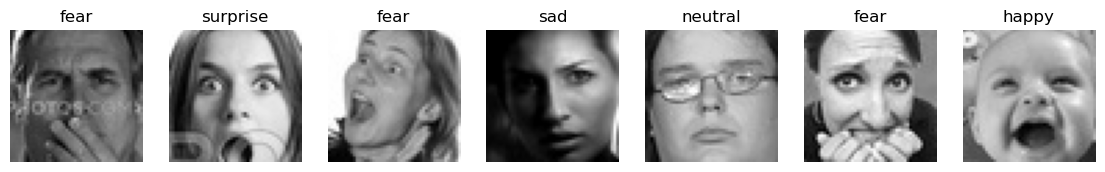

In [7]:
# IMAGE PLOTTING

def show_images(dataset, classes, n=7):
    fig, axes = plt.subplots(1, n, figsize=(14, 3))
    for i in range(n):
        img, label = dataset[i]
        img = img.squeeze().numpy()
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(classes[label])
        axes[i].axis("off")
    plt.show()

classes = train_dataset.classes

show_images(train_final, classes)
show_images(val_final, classes)


In [8]:
# DATALOADERS

BATCH_SIZE = 64

train_loader = DataLoader(
    train_final,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_final,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 48, 48])
torch.Size([64])
